In [357]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt

train_data_pl = pl.read_csv(r"../data/train.csv",encoding="shift_jis")

In [358]:
train_data_pl.head(1)

sample number,species number,樹種,含水率,9993.76781,9989.9107,9986.05359,9982.19648,9978.33937,9974.48227,9970.62516,9966.76805,9962.91094,9959.05383,9955.19672,9951.33962,9947.48251,9943.6254,9939.76829,9935.91118,9932.05407,9928.19697,9924.33986,9920.48275,9916.62564,9912.76853,9908.91142,9905.05432,9901.19721,9897.3401,9893.48299,9889.62588,9885.76877,9881.91166,9878.05456,9874.19745,9870.34034,…,4138.67729,4134.82018,4130.96307,4127.10596,4123.24886,4119.39175,4115.53464,4111.67753,4107.82042,4103.96331,4100.10621,4096.2491,4092.39199,4088.53488,4084.67777,4080.82066,4076.96356,4073.10645,4069.24934,4065.39223,4061.53512,4057.67801,4053.82091,4049.9638,4046.10669,4042.24958,4038.39247,4034.53536,4030.67826,4026.82115,4022.96404,4019.10693,4015.24982,4011.39271,4007.5356,4003.6785,3999.82139
i64,i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,1,"""イチョウ""",216.129032,0.41485,0.41465,0.41463,0.41476,0.41481,0.4147,0.41452,0.41427,0.41392,0.41364,0.41354,0.41355,0.41352,0.41337,0.41312,0.41284,0.4127,0.41265,0.41257,0.41242,0.4123,0.41226,0.41218,0.41193,0.41159,0.41129,0.41111,0.41102,0.41096,0.41098,0.41109,0.41116,0.41104,…,1.1985,1.19969,1.20339,1.20819,1.21138,1.21194,1.21262,1.21483,1.21592,1.21666,1.22043,1.22559,1.22777,1.22751,1.22862,1.23165,1.23629,1.24109,1.24147,1.23927,1.24074,1.24282,1.24082,1.23906,1.24128,1.24471,1.24783,1.25104,1.24925,1.24145,1.2362,1.23384,1.22981,1.22818,1.23087,1.23354,1.23219


In [359]:
import importlib
import ml_pipeline
import mlflow

In [360]:
#リロード
importlib.reload(ml_pipeline)

/usr/local/lib/python3.11/site-packages/mlflow/pyfunc/utils/data_validation.py:186: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


<module 'ml_pipeline' from '/work/ml_pipeline.py'>

In [361]:
mlflow.set_tracking_uri("http://mlflow:5000")
mlflow.set_experiment("exp2")

<Experiment: artifact_location='/mlruns/1', creation_time=1775686978108, experiment_id='1', last_update_time=1775686978108, lifecycle_stage='active', name='exp2', tags={}, workspace='default'>

In [364]:
with mlflow.start_run() as run:

    pipe = MoisturePipeline(
        use_pca=False,
        use_diff=True,
        use_conv=True,
        use_band=True,
        params={
            "verbosity": -1,
            "n_estimators": 500,
            "learning_rate": 0.05,
            "num_leaves": 64,
            "min_data_in_leaf": 5,
            "n_jobs": -1,
        }
    )

    rmse = pipe.fit(train_data_pl)

    mlflow.log_params(pipe.params)
    mlflow.log_metric("rmse", rmse)

    mlflow.pyfunc.log_model(
        name="model",
        python_model=FullPipelineModel(pipe)
    )

    print("run_id:", run.info.run_id)

/usr/local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
2026/04/16 22:09:19 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


run_id: 84ab258cf12243428a4b94c8d6d6dddc
🏃 View run lyrical-crane-610 at: http://mlflow:5000/#/experiments/1/runs/84ab258cf12243428a4b94c8d6d6dddc
🧪 View experiment at: http://mlflow:5000/#/experiments/1


### sharpray値を使い　2次微分は1,特定の特徴量だけが落としている　or 2.全体的に効いていない　をみる

2次微分はほぼ効いていないので打ち切る

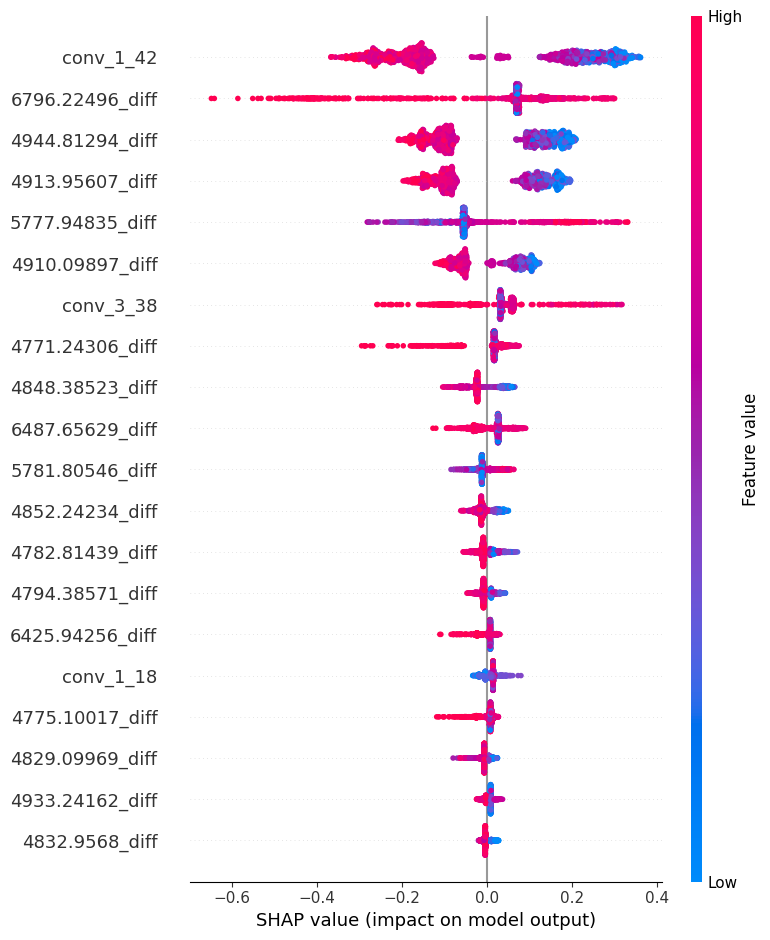


=== SHAP importance ===
conv_1_42          0.220794
6796.22496_diff    0.137153
4944.81294_diff    0.130784
4913.95607_diff    0.123137
5777.94835_diff    0.095600
4910.09897_diff    0.074357
conv_3_38          0.059464
4771.24306_diff    0.036010
4848.38523_diff    0.034722
6487.65629_diff    0.030230
5781.80546_diff    0.020075
4852.24234_diff    0.018985
4782.81439_diff    0.017084
4794.38571_diff    0.012928
6425.94256_diff    0.012391
conv_1_18          0.012245
4775.10017_diff    0.012053
4829.09969_diff    0.011047
4933.24162_diff    0.008626
4832.9568_diff     0.008306
dtype: float64


In [365]:
from ml_pipeline import FeatureEngineer  # 定義している場所からimport

# SHAP可視化

shap_importance = pipe.fe.show_shap(train_data_pl, pipe.model, pipe.feature_cols)

#pipe.fe.show_shap(train_data_pl, pipe.model, pipe.feature_cols)

In [348]:
# pipe.fe.one_demention_conv_cols

In [323]:
print(len(pipe.fe.feature_cols))

print(len(pipe.fe.original_base_cols))

print(len(pipe.fe.first_diff_cols))

print(len(pipe.fe.band_feature))

3312
1555
1554
3



## モデルを引き落としてきて実験する

In [366]:
test_data_pl = pl.read_csv(r"../data/test.csv",encoding="shift_jis")

In [367]:

experiment_name = "exp2"  

experiment = mlflow.get_experiment_by_name(experiment_name)

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["start_time DESC"],
    max_results=1
)

latest_run_id = runs.iloc[0]["run_id"]
print(latest_run_id)

84ab258cf12243428a4b94c8d6d6dddc


In [368]:
model_uri = mlflow.pyfunc.load_model(f"runs:/{latest_run_id}/model")

In [369]:
model_uri

mlflow.pyfunc.loaded_model:
  artifact_path: /mlruns/1/models/m-e2c7a468a0894e4192268db2f8d7cf10/artifacts
  flavor: mlflow.pyfunc.model
  run_id: 84ab258cf12243428a4b94c8d6d6dddc

In [372]:
model = mlflow.pyfunc.load_model(
    "runs:/089c88f5222246e1a222fe44eb86dfbe/model"
)

print(model._model_impl.python_model.pipe.fe.__dict__)

#y_pred = model.predict(test_data_pl)

{'base_cols': None, 'first_diff_cols': [], 'second_diff_cols': [], 'feature_cols': ['sample number', 'species number', '9993.76781', '9989.9107', '9986.05359', '9982.19648', '9978.33937', '9974.48227', '9970.62516', '9966.76805', '9962.91094', '9959.05383', '9955.19672', '9951.33962', '9947.48251', '9943.6254', '9939.76829', '9935.91118', '9932.05407', '9928.19697', '9924.33986', '9920.48275', '9916.62564', '9912.76853', '9908.91142', '9905.05432', '9901.19721', '9897.3401', '9893.48299', '9889.62588', '9885.76877', '9881.91166', '9878.05456', '9874.19745', '9870.34034', '9866.48323', '9862.62612', '9858.76901', '9854.91191', '9851.0548', '9847.19769', '9843.34058', '9839.48347', '9835.62636', '9831.76926', '9827.91215', '9824.05504', '9820.19793', '9816.34082', '9812.48371', '9808.62661', '9804.7695', '9800.91239', '9797.05528', '9793.19817', '9789.34106', '9785.48396', '9781.62685', '9777.76974', '9773.91263', '9770.05552', '9766.19841', '9762.34131', '9758.4842', '9754.62709', '9750

NameError: name 'df' is not defined

In [115]:
submission = pd.DataFrame({
    "id": test_data_pl["sample number"],
    "含水率": y_pred
})

submission.head()
submission.to_csv(r"../data/submission.csv",index=False,header = False)

In [117]:
!ls ../data

pred.csv  pred.txt  sample_submit.csv  submission.csv  test.csv  train.csv
